# HW4: Occupation Dataset

### Introduction:

Special thanks to: https://github.com/guipsamora for sharing his datasets, materials, and questions.

- https://github.com/justmarkham for sharing the dataset and materials.


In [1]:
### Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
### I believe the following data set is from the US in the 1950s.
### Gender proportions and ages are thus reflective of that era.
### Import the dataset from this address. https://raw.githubusercontent.com/justmarkham/DAT8/master/data/u.user
### Assign it to a variable called users and use the 'user_id' as index
users = pd.read_csv('https://raw.githubusercontent.com/justmarkham/DAT8/master/data/u.user', 
                      sep='|', index_col='user_id')

In [3]:
# Problem 1. See the first 10 entries. (done for you)
users.head(10)

,age,gender,occupation,zip_code
user_id,,,,
1,24,M,technician,85711
2,53,F,other,94043
3,23,M,writer,32067
4,24,M,technician,43537
5,33,F,other,15213
6,42,M,executive,98101
7,57,M,administrator,91344
8,36,M,administrator,05201
9,29,M,student,01002


In [ ]:
# Problem 2. How many observations and columns are in the data?

print(len(users))
print(len(users.columns))


943
4


In [27]:
# Problem 3. How many different occupations there are in this dataset?
print(len(users["occupation"].unique()))

21


In [32]:
# Problem 4. What is the most frequent occupation?
print(users.groupby("occupation").size().sort_values(ascending = False).head(1))

occupation
student    196
dtype: int64


In [19]:
# Problem 5. Discover what is the mean age per occupation.
# Sort the results and find the 3 occupations with the lowest mean age and the 3 with the highest
p5 = users.groupby("occupation")["age"].mean().sort_values()
print(p5.head(3))
print(p5.tail(3))


occupation
student          22.081633
none             26.555556
entertainment    29.222222
Name: age, dtype: float64
occupation
educator    42.010526
doctor      43.571429
retired     63.071429
Name: age, dtype: float64


In [24]:
# Problem 6. Find the proportion of males by occupation and sort it from the most to the least
p6o = users[users["gender"] == "M"].groupby("occupation")["gender"].count()
p62 = users.groupby("occupation")["gender"].count()
p6 =(p6o/p62).sort_values(ascending = False)
print(p6)

occupation
doctor           1.000000
engineer         0.970149
technician       0.962963
retired          0.928571
programmer       0.909091
executive        0.906250
scientist        0.903226
entertainment    0.888889
lawyer           0.833333
salesman         0.750000
educator         0.726316
student          0.693878
other            0.657143
marketing        0.615385
writer           0.577778
none             0.555556
administrator    0.544304
artist           0.535714
librarian        0.431373
healthcare       0.312500
homemaker        0.142857
Name: gender, dtype: float64


In [26]:
# Problem 7. For each occupation, calculate the minimum and maximum ages
# See groupby and agg() to perform multiple aggregate functions at once
users.groupby("occupation").agg({"age" : ["min", "max"]})

age    
              min max
occupation           
administrator  21  70
artist         19  48
doctor         28  64
educator       23  63
engineer       22  70
entertainment  15  50
executive      22  69
healthcare     22  62
homemaker      20  50
lawyer         21  53
librarian      23  69
marketing      24  55
none           11  55
other          13  64
programmer     20  63
retired        51  73
salesman       18  66
scientist      23  55
student         7  42
technician     21  55
writer         18  60

In [33]:
# Problem 8. For each combination of occupation and gender, calculate the mean age.
# Arrange the results in a table so each row is an occupation, and you have a 
# column of the average male age and another column with the average female age.
# Sort the resulting table by Female mean age from least to greatest
users.groupby(["occupation", "gender"]).age.mean().unstack().sort_values(by = "F", ascending = True)

gender,F,M
occupation,,
student,20.750000,22.669118
salesman,27.000000,38.555556
scientist,28.333333,36.321429
engineer,29.500000,36.600000
artist,30.307692,32.333333
entertainment,31.000000,29.000000
programmer,32.166667,33.216667
homemaker,34.166667,23.000000
other,35.472222,34.028986


In [36]:
# Problem 9. For each occupation find the count of women and men
# Arrange the results in a table so each row is an occupation, similar to above
users.groupby(['occupation', 'gender']).size().unstack().sort_values(by = 'F', ascending = True)

gender,F,M
occupation,,
technician,1.0,26.0
retired,1.0,13.0
engineer,2.0,65.0
entertainment,2.0,16.0
lawyer,2.0,10.0
executive,3.0,29.0
scientist,3.0,28.0
salesman,3.0,9.0
none,4.0,5.0


In [37]:
# Problem 10. Turn the counts above into proportions. e.g administrator 0.455696 0.544304
# Arrange results in increasing order of proportion men
users.groupby(['occupation']).gender.value_counts(normalize = True).unstack().sort_values(by = 'M')

gender,F,M
occupation,,
homemaker,0.857143,0.142857
healthcare,0.687500,0.312500
librarian,0.568627,0.431373
artist,0.464286,0.535714
administrator,0.455696,0.544304
none,0.444444,0.555556
writer,0.422222,0.577778
marketing,0.384615,0.615385
other,0.342857,0.657143


<Axes: xlabel='occupation'>

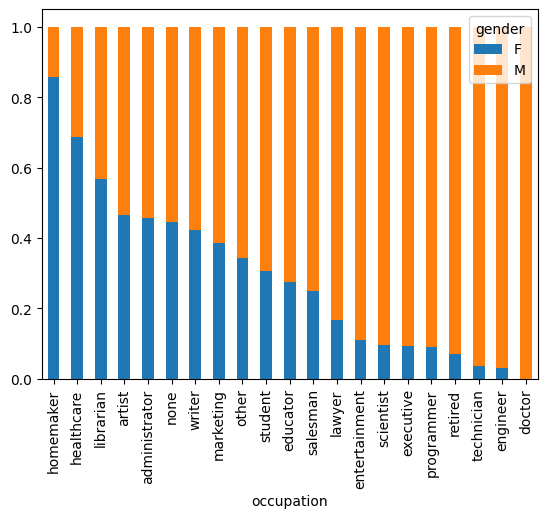

In [38]:
# Create a stacked barchart showing the results above
usersocc = users.groupby(['occupation']).gender.value_counts(normalize = True).unstack().sort_values(by = 'M')

usersocc.plot(kind = "bar", stacked = True)

In [39]:
# Extract the first digit of each zip code 
# and create a new column called 'region' that maps the
# first digit of the zip to new values using this dictionary:
d = {'0': 'New England',
'1': 'Mid-Atlantic',
'2': 'Central East Coast',
'3': 'The South',
'4': 'Midwest',
'5': 'Northern Great Plains',
'6': 'Central Great Plains',
'7': 'Southern Central',
'8': 'Mountain Desert',
'9': 'West Coast'} 

# print the first 5 rows of the result
# postal codes that begin with a letter are actually Canadian but are missing the last digit. These rows can be ignored.

In [41]:
users["region"] = users.zip_code.str[0].map(d)
users.head(5)

,age,gender,occupation,zip_code,region
user_id,,,,,
1,24,M,technician,85711,Mountain Desert
2,53,F,other,94043,West Coast
3,23,M,writer,32067,The South
4,24,M,technician,43537,Midwest
5,33,F,other,15213,Mid-Atlantic


In [ ]:
# for the occuptation 'retired', find the mean age of each region
users.groupby()